In [ ]:
# Détecter les fraudes de cartes bancaires
#Realiser par:
# ELHAJJOULI DOUAA / RAGALA Orjouane

In [1]:
# 0. Installer dépendances
!pip install -q imbalanced-learn mlxtend
#imbalanced-learn : gérer les données déséquilibrées

In [ ]:
# 1. Importer le dataset avec kagglehub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
# 2. Charger le fichier CSV
# Le fichier CSV est lu
# Les données sont mises dans un DataFrame pandas
# df = tableau de données (lignes = transactions)

In [3]:
import pandas as pd
import os

csv_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_path)

df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# 3. Objectif du Projet
## Objectif Global
#Détecter automatiquement les transactions frauduleuses dans un dataset financier
#utilisé internationalement pour les recherches sur la fraude carte bancaire.

## Sous-objectifs
#- Explorer les données (EDA)
#- Nettoyer et préparer le dataset
#- Appliquer le processus KDD complet
#- Tester différents algorithmes :
  #- Classification
  #- Clustering
  #- Régression (exemple)
  #- Règles d’association (Apriori)
  #- Détection d'anomalies
#- Évaluer les modèles avec des métriques adaptées
#- Interpréter les résultats du point de vue métier

In [ ]:
# Class = 0 → transaction normale

# Class = 1 → fraude

In [ ]:
df.info()
df.describe().T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


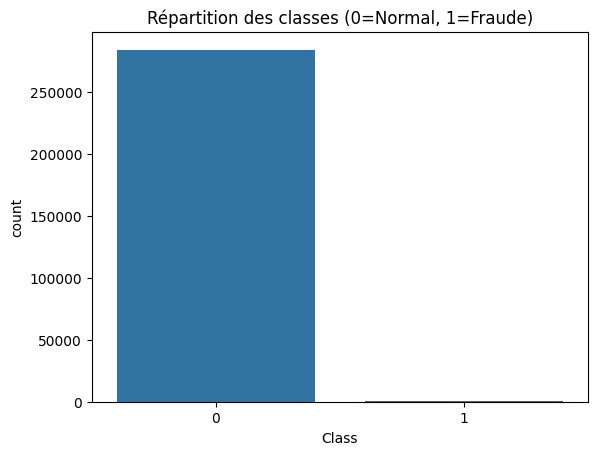

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=df["Class"])
plt.title("Répartition des classes (0=Normal, 1=Fraude)")
plt.show()


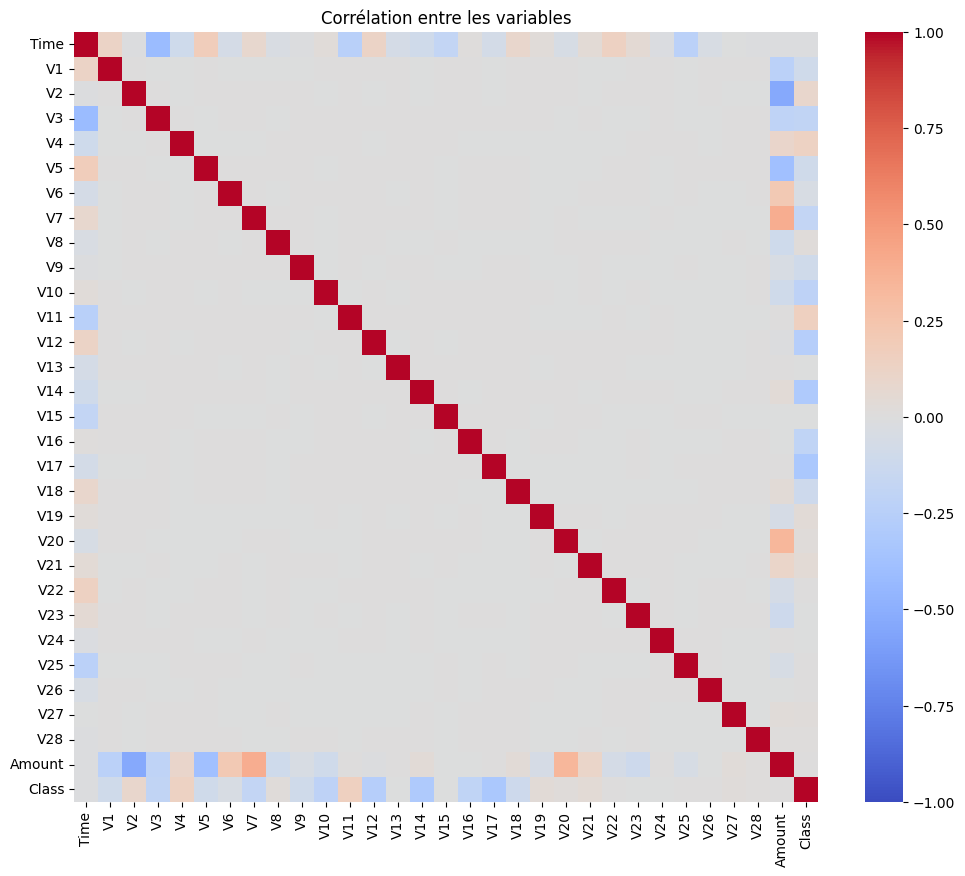

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Corrélation entre les variables")
plt.show()


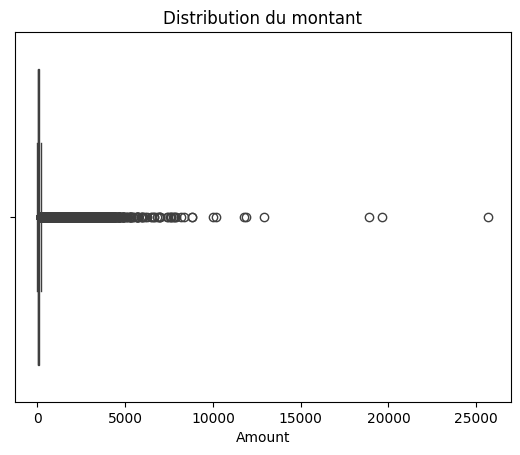

In [ ]:
sns.boxplot(x=df["Amount"])
plt.title("Distribution du montant")
plt.show()


In [ ]:
# 5. Pré-Traitements

In [ ]:
## Suppression des doublons

In [4]:
df = df.drop_duplicates()

In [ ]:
## Vérification des valeurs manquantes

In [5]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
## Normalisation des variables Amount & Time

In [6]:
from sklearn.preprocessing import StandardScaler
import numpy as np

df["logAmount"] = np.log1p(df["Amount"])

scaler = StandardScaler()
df["scaledAmount"] = scaler.fit_transform(df["Amount"].values.reshape(-1,1))
df["scaledTime"] = scaler.fit_transform(df["Time"].values.reshape(-1,1))


In [ ]:
## 6. Split & SMOTE / Séparation X / y

# X = données d’entrée (montant, variables V1…V28)

#y = ce qu’on veut prédire (fraude ou non)

#Crée artificiellement des exemples de fraude

#Évite que le modèle ignore les fraudes

In [7]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)


In [ ]:
## 7. Modélisation — Classification
#Fonctions d’évaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc

def eval_model(model):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))


In [ ]:
# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight="balanced", random_state=42)
dt.fit(X_train_sm, y_train_sm)

eval_model(dt)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.45      0.73      0.56        95

    accuracy                           1.00     56746
   macro avg       0.73      0.86      0.78     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.8624165132960909


In [ ]:
# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)

eval_model(rf)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.92      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9510969751079787


In [ ]:
# Régression logistique

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train_sm, y_train_sm)

eval_model(lr)


              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.13      0.86      0.22        95

    accuracy                           0.99     56746
   macro avg       0.56      0.93      0.61     56746
weighted avg       1.00      0.99      0.99     56746

ROC-AUC: 0.9595467725287518


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#KNN  Modélisation — Classification

In [ ]:
# KNN — K Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn.fit(X_train_sm, y_train_sm)

eval_model(knn)



              precision    recall  f1-score   support

           0       1.00      0.94      0.97     56651
           1       0.01      0.43      0.03        95

    accuracy                           0.94     56746
   macro avg       0.51      0.69      0.50     56746
weighted avg       1.00      0.94      0.97     56746

ROC-AUC: 0.6896145281032806


In [ ]:
# 8. Clustering — KMeans

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

X_clust = X_train_sm.drop(columns=["Time", "Amount", "logAmount"])
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_clust)

#elbow
print("Silhouette Score :", silhouette_score(X_clust, labels))

pca = PCA(2)
proj = pca.fit_transform(X_clust)

plt.scatter(proj[:,0], proj[:,1], c=labels, s=5)
plt.title("Clustering — PCA Projection")
plt.show()


In [ ]:
# 8. Clustering — KMeans # Elbow Method pour choisir k

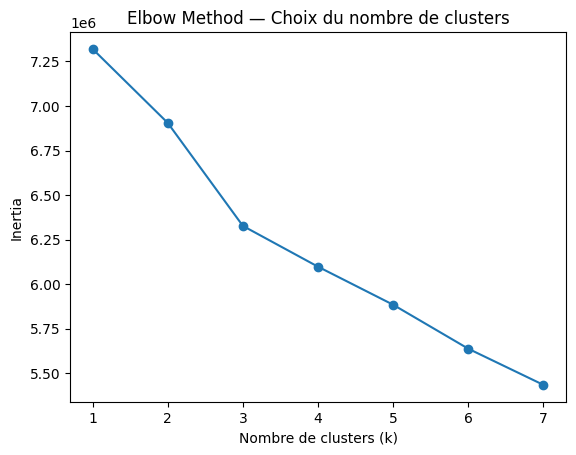

Silhouette Score : 0.5127537783150458


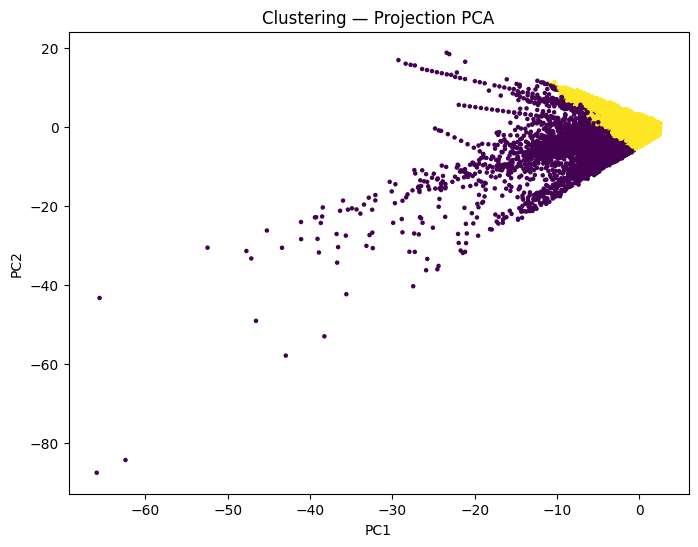

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1️ Sélection des features pour le clustering
cols_to_drop = [c for c in ["Time", "Amount", "logAmount"] if c in X_train.columns]
X_clust = X_train.drop(columns=cols_to_drop)

# 2️ Elbow Method
inertia = []
K = range(1, 8)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_clust)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Choix du nombre de clusters")
plt.show()

# 3️ KMeans avec k=2 (justifié par Elbow)
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_clust)

print("Silhouette Score :", silhouette_score(X_clust, labels))

# 4️ Visualisation PCA
pca = PCA(n_components=2)
proj = pca.fit_transform(X_clust)

plt.figure(figsize=(8,6))
plt.scatter(proj[:,0], proj[:,1], c=labels, s=5)
plt.title("Clustering — Projection PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [ ]:
# 9. Régression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_reg = df.drop(["Amount", "Class"], axis=1)
y_reg = df["Amount"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(Xr_train, yr_train)

print("MSE:", mean_squared_error(yr_test, reg.predict(Xr_test)))


MSE: 1.4502407703860242e-17


In [ ]:
# 10. Règles d’Association (Apriori)

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

binary = df.copy()
for col in binary.columns:
    if binary[col].dtype != "object":
        binary[col] = binary[col] > binary[col].median()

binary_small = binary.sample(20000).astype(bool)

frequent = apriori(binary_small, min_support=0.3, use_colnames=True)
rules = association_rules(frequent, metric="lift", min_threshold=1.2)

rules.head()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(V5),(Time),0.5020,0.50460,0.3186,0.634661,1.257751,1.0,0.065291,1.356002,0.411507,0.463081,0.262538,0.633026
1,(Time),(V5),0.5046,0.50200,0.3186,0.631391,1.257751,1.0,0.065291,1.351026,0.413666,0.463081,0.259822,0.633026
2,(scaledTime),(Time),0.5046,0.50460,0.5046,1.000000,1.981768,1.0,0.249979,inf,1.000000,1.000000,1.000000,1.000000
3,(Time),(scaledTime),0.5046,0.50460,0.5046,1.000000,1.981768,1.0,0.249979,inf,1.000000,1.000000,1.000000,1.000000
4,(V4),(V1),0.5004,0.50015,0.3045,0.608513,1.216661,1.0,0.054225,1.276799,0.356442,0.437469,0.216791,0.608665


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# 11. Détection d’Anomalies — Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.001, random_state=42)
iso.fit(X_train)

anomalies = iso.predict(X_test)  # -1 = anomalie
print("Anomalies détectées :", list(anomalies).count(-1))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Anomalies détectées : 56


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:

#12.  Comparaison finale des modèles


#Random Forest  : meilleur modèle global
# → Très bon équilibre précision / rappel, ROC-AUC élevé (~0.95)
# → Recommandé pour la détection de fraude en production

# Régression Logistique :
# → Rappel élevé (peu de fraudes manquées)
# → Trop de fausses alertes

# Decision Tree :
# → Simple et interprétable
# → Performances inférieures aux autres modèles

# KMeans (clustering) :
# → Utile pour l’exploration
# → Non adapté à la prédiction directe de fraude

# Isolation Forest :
# → Bon complément pour détecter des anomalies inconnues

In [ ]:
# Conclusion :
# Le Random Forest est le modèle le plus performant.
# Une approche hybride Random Forest + Isolation Forest est la plus pertinente.